In [1]:
import numpy as np
import scipy.io
import os
import torch
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import arff
from pathlib import Path
from skmultilearn.dataset import load_dataset
import numpy as np
from sklearn.compose import ColumnTransformer
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph
from skmultilearn.adapt import MLkNN
from sklearn.metrics import hamming_loss
from sklearn.metrics import zero_one_loss
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import sklearn
from numpy.matlib import repmat
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.metrics as metrics
import warnings
import time
import glob
warnings.filterwarnings('ignore')

## GPU or CPU

GPU = False
if GPU:
    torch.backends.cudnn.enabled = True
    torch.backends.cudnn.benchmark = True
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    print("num GPUs", torch.cuda.device_count())
    dtype = torch.cuda.FloatTensor
else:
    dtype = torch.FloatTensor
    print("CPU")
    

CPU


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# Set custom font properties
font = {'family': 'normal',
        'weight': 'bold',
        'size': 14}
rc('font', **font)

params = {'text.usetex': True,
          'text.latex.preamble': [r'\usepackage{cmbright}', r'\usepackage{amsmath}']}
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "15"

In [64]:
def corr(Y):
    S = sklearn.metrics.pairwise.cosine_similarity(Y.T)
    S = torch.tensor(S).type(dtype)
    Dc = torch.diag(torch.sum(S, axis=1))

    return S , Dc

def one_error(outputs, test_target):
    err_cnt = 0
    for i in range(outputs.shape[0]):
        idx = np.argmax(outputs[i])
        if test_target[i, idx] != 1:
            err_cnt += 1
    one_error = err_cnt / outputs.shape[0]
    return one_error



 ZRE: 0.66844445 
 HML: 0.04072917 
 ONE: 0.44733334 
 MIC: 0.50241214 
 MAC: 0.19608992 



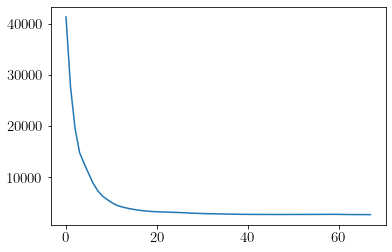

In [89]:
data = loadmat(f'../../Datasets/health.mat')
train = data['train']
test = data['test']    

X_test = train[0][0].T
Y_test = train[0][1].T
Y_test[Y_test == -1] = 0

X = torch.from_numpy(test[0][0].T).type(dtype)
Xc = test[0][0].T
Y = torch.from_numpy(test[0][1].T).type(dtype)
# Y = loadmat(f'Y_Arts_{0.1, 0.15, 0.2, 0.3, 0.4 or 0.5}%.mat')
# Y = torch.from_numpy(Y['Y']).type(dtype)

Y[Y == -1] = 0
n,d = X.shape
n,l = Y.shape

Yc = Y.cpu()
Yn = Yc.numpy()


eps = torch.tensor(torch.finfo(torch.float32).eps)


# lam1 = [1e-4,0.1,0.3,0.5,0.7,0.9,1]
# lam2 = [1e-4,0.1,0.3,0.5,0.7,0.9,1]
# lam3 = [1e-4,0.1,0.5,0.9,1.5,2,2.5,3,3.5,4]

lam1 = 0.7
lam2 = 0.7
lam3 = 2.5


C,A = corr(Y)

ppn=0

iter = 70
err = torch.zeros(iter)

ZERAVG = torch.zeros((3))   
HMLAVG = torch.zeros((3))
ONEAVG = torch.zeros((3))  
MICAVG = torch.zeros((3))
MACAVG = torch.zeros((3))

for iv in range(3):
    W = torch.rand(d, l)
    for t in range(iter):
        eij =   torch.abs(Y - X @ W)
        Z = 1 / torch.maximum(eij * (1+eij),eps)

        dw = torch.norm(W, dim=1, p=2)
        iw = 1/torch.maximum(dw * (1 + dw),eps)
        D = torch.diag(iw)

        Wa = X.T @ (Z * Y)       + lam1 * (W @ C)  + lam2 * W
        Wb = X.T @ (Z * (X @ W)) + lam1 * (W @ A)  + lam2 * (1 / torch.maximum(1+ W @ W.T,eps) @ W) + lam3 * (D @ W)
        W  = W * (Wa/  torch.maximum((Wb),eps))

        At = W.T @ W
        B = torch.tile(torch.diag(At),(l,1))
        Cn = lam1/2 * (At)
        Cd = lam1/2 * (B)

        C  = C * (Cn/ torch.maximum(Cd, eps))
        A = torch.diag(torch.sum(C,dim=1))

        eij =   torch.abs(Y - X @ W)
        Z = 1 / torch.maximum(eij * (1+eij),eps)

        T1 = torch.norm(Z * (Y - X @ W))**2
        T2 = lam1 * torch.trace(X @ W @ (A - C) @ W.T @ X.T)
        T3 = lam2 * (torch.sum(torch.log(1 +  W @ W.T)) - torch.norm(W)**2)
        T4 = lam3 * torch.trace(W.T @ D @ W) 
        err[t] = T1 + T2 + T3 + T4
        
    WW = torch.norm(W, dim=1, p=2)
    sQ = torch.argsort(WW)
    sQ = sQ.cpu()

    nosf = int (20 * d / 100)
    sX = X[:,sQ[d-nosf:]]
    classifier = MLkNN(k=10)
    classifier.fit(sX, Yn.astype(int))
    predictions = classifier.predict(X_test[:,sQ[d-nosf:].long()]).toarray()
    scores = classifier.predict_proba(X_test[:,sQ[d-nosf:].long()]).toarray()
    ZER = zero_one_loss(Y_test,predictions)
    ZERAVG[iv] = ZER
    HML = hamming_loss(Y_test,predictions)
    HMLAVG[iv] = HML
    ONE = one_error(predictions,Y_test)
    ONEAVG[iv] = ONE
    MIC = f1_score(Y_test, predictions, average='micro')
    MICAVG[iv] = MIC
    MAC = f1_score(Y_test, predictions, average='macro')
    MACAVG[iv] = MAC

ZERNPY = ZERAVG.numpy()
HMLNPY = HMLAVG.numpy()
ONENPY = ONEAVG.numpy()
MICNPY = MICAVG.numpy()
MACNPY = MACAVG.numpy()

print("\n",
    'ZRE:', np.mean(ZERNPY),"\n",
    'HML:', np.mean(HMLNPY),"\n",
    'ONE:', np.mean(ONENPY),"\n",
    'MIC:', np.mean(MICNPY),"\n",
    'MAC:', np.mean(MACNPY),"\n",

)
plt.plot(err[2:])
plt.show()

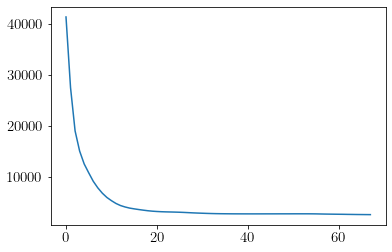